# EDA Customer Segmentation, LTV & Profit Optimization

Main objectives:
- Demonstrate profitability by focusing on a small customer group using the **Lorenz Curve**.
- Develop **RFM segmentation** based on profit rather than just revenue.
- Describe three priority groups and propose a **personalized marketing/care strategy**.

## 1. Imports, Config & Helper Functions

- Only keep orders that are likely to reflect actual transactions (`paid`, `shipped`, `delivered`, `returned`).
- Profit margin: `quantity * unit_price - quantity * cogs`.
- `returns` and `reviews` are added as supporting features to enrich customer profiles, but **Monetary** in RFM still prioritizes `monetary_profit` from order-items.

In [1]:
from pathlib import Path
from typing import *
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

In [2]:
def resolve_data_dir() -> Path:
    candidates = [Path.cwd() / 'data', Path.cwd().parent / 'data']
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Cannot locate data/ directory from current working directory.')

def pct(value: float) -> str:
    return f'{value:.1%}'

def fmt_money(value: float) -> str:
    return f'{value:,.0f}'

def binary_treemap(
        sizes: list[float],
        x: float = 0,
        y: float = 0,
        w: float = 1,
        h: float = 1,
        horizontal: bool = True
    ) -> List[Tuple[float, float, float, float]]:
    """
    Recursively split the rectangle into two parts based on the sizes.
    
    Args:
        sizes: List of sizes for each segment. Must be non-negative.
        x, y: Bottom-left corner of the rectangle.
        w, h: Width and height of the rectangle.
        horizontal: Whether to split horizontally or vertically at this level.
    
    Returns:
        List of tuples (x, y, w, h) for each segment.
    """
    sizes = [float(s) for s in sizes if s > 0]
    if not sizes:
        return []
    if len(sizes) == 1:
        return [(x, y, w, h)]

    total = sum(sizes)
    # Find the split point where the cumulative sum exceeds half of the total
    split_at = np.searchsorted(np.cumsum(sizes), total / 2.0) + 1
    left = sizes[:split_at]
    right = sizes[split_at:]

    if not right:
        split_at = len(sizes) - 1
        left = sizes[:split_at]
        right = sizes[split_at:]

    # Calculate the share of the left part and split the rectangle accordingly
    share_left = sum(left) / total
    if horizontal:
        w_left = w * share_left
        return (
            binary_treemap(left, x, y, w_left, h, not horizontal)
            + binary_treemap(right, x + w_left, y, w - w_left, h, not horizontal)
        )

    h_left = h * share_left
    return (
        binary_treemap(left, x, y, w, h_left, not horizontal)
        + binary_treemap(right, x, y + h_left, w, h - h_left, not horizontal)
    )

In [3]:
DATA_DIR = resolve_data_dir()
VALID_ORDER_STATUS = ['paid', 'shipped', 'delivered', 'returned', 'cancelled']
SEGMENT_COLORS = {
    'Champions': '#0b6e4f',
    'Loyal': '#2a9d8f',
    'Potential': '#e9c46a',
    'Need Attention': '#f4a261',
    'At Risk': '#e76f51',
    'Lost': '#8d99ae',
}

print('Using data directory:', DATA_DIR.resolve())

Using data directory: /Users/truong.le/Desktop/vinuni-datathon-tanbinhtoannang/data


## 2. Load Data & Initial Business Snapshot

Before segmenting, we need to confirm the scale of operations, timeframe, and proportion of order status. This helps avoid mixing incomplete orders ('created', 'cancelled') into the LTV calculation.

In [4]:
orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'], low_memory=False)
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', low_memory=False)
products = pd.read_csv(DATA_DIR / 'products.csv')
customers = pd.read_csv(DATA_DIR / 'customers.csv', parse_dates=['signup_date'])
promotions = pd.read_csv(DATA_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
reviews = pd.read_csv(DATA_DIR / 'reviews.csv', parse_dates=['review_date'])
returns = pd.read_csv(DATA_DIR / 'returns.csv', parse_dates=['return_date'])

orders_filtered = orders[orders['order_status'].isin(VALID_ORDER_STATUS)].copy()

business_snapshot = pd.DataFrame(
    {
        'metric': [
            'Total orders',
            'Orders kept for LTV',
            'Customers in raw master data',
            'Order-item rows',
            'Date range',
        ],
        'value': [
            f'{len(orders):,}',
            f'{len(orders_filtered):,}',
            f"{customers['customer_id'].nunique():,}",
            f'{len(order_items):,}',
            f"{orders['order_date'].min().date()} -> {orders['order_date'].max().date()}",
        ],
    }
)
display(business_snapshot)

status_share = (
    orders['order_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename('pct_orders')
    .reset_index()
    .rename(columns={'index': 'order_status'})
)
display(status_share)

,metric,value
0,Total orders,"646,945"
1,Orders kept for LTV,"639,670"
2,Customers in raw master data,"121,930"
3,Order-item rows,"714,669"
4,Date range,2012-07-04 -> 2022-12-31


,order_status,pct_orders
0,delivered,79.9
1,cancelled,9.2
2,returned,5.6
3,shipped,2.1
4,paid,2.1
5,created,1.1


## 3. Build Customer Golden Table

Each final row will represent **a customer**, while the columns are aggregated features from their transaction history.

### 3.1. Item-Level Facts Foundation

Create the core transaction-level dataset by merging:
- Order items with product attributes (category, COGS)
- Orders metadata (customer, date, status, source)
Then calculate line-item profitability metrics and promo usage flags.
This serves as the atomic unit for all downstream aggregations.

In [5]:
item_facts = (
    order_items
    .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')
    .merge(
        orders_filtered[['order_id', 'customer_id', 'order_date', 'order_status', 'order_source']],
        on='order_id',
        how='inner',
    )
)

item_facts['line_revenue'] = item_facts['quantity'] * item_facts['unit_price']
item_facts['line_profit'] = item_facts['quantity'] * (item_facts['unit_price'] - item_facts['cogs'])
item_facts['used_promo'] = item_facts[['promo_id', 'promo_id_2']].notna().any(axis=1)

display(item_facts)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,category,cogs,customer_id,order_date,order_status,order_source,line_revenue,line_profit,used_promo
0,1,2400,7,1138.22,0.0,NaN,NaN,GenZ,1053.798008,58578,2012-07-04,delivered,paid_search,7967.54,590.953941,False
1,2,609,7,10166.25,0.0,NaN,NaN,Streetwear,8987.704231,58621,2012-07-04,returned,paid_search,71163.75,8249.820384,False
2,3,396,3,11220.33,0.0,NaN,NaN,Streetwear,10091.012256,58811,2012-07-04,delivered,direct,33660.99,3387.953233,False
3,4,635,5,10639.25,0.0,NaN,NaN,Streetwear,9205.430478,59453,2012-07-04,delivered,referral,53196.25,7169.097610,False
4,6,1935,1,1597.84,0.0,NaN,NaN,Outdoor,1048.696357,57821,2012-07-06,delivered,email_campaign,1597.84,549.143643,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
706670,834372,690,8,4473.92,0.0,NaN,NaN,Streetwear,3100.062695,19490,2022-12-31,delivered,email_campaign,35791.36,10990.858436,False
706671,834377,1995,7,5250.79,0.0,NaN,NaN,Streetwear,3025.421056,73046,2022-12-31,delivered,referral,36755.53,15577.582610,False
706672,834387,2331,8,7389.06,0.0,NaN,NaN,Streetwear,6671.816431,107723,2022-12-31,delivered,email_campaign,59112.48,5737.948549,False
706673,834392,1115,5,4767.33,0.0,NaN,NaN,Outdoor,4587.478861,139431,2022-12-31,delivered,direct,23836.65,899.255696,False


### 3.2. Order-Level Aggregation (RFM Building Blocks)
Aggregate item_facts to order level to compute:
- order_revenue: total revenue per order
- order_profit: total profit per order
- used_promo: whether order had any promotional code
- total_units: quantity purchased per order
This intermediate layer bridges item-level and customer-level metrics.

In [6]:
order_level = (
    item_facts.groupby(['order_id', 'customer_id', 'order_date'], as_index=False)
    .agg(
        order_revenue=('line_revenue', 'sum'),
        order_profit=('line_profit', 'sum'),
        used_promo=('used_promo', 'max'),
        total_units=('quantity', 'sum'),
    )
)

display(order_level)

,order_id,customer_id,order_date,order_revenue,order_profit,used_promo,total_units
0,1,58578,2012-07-04,7967.54,590.953941,False,7
1,2,58621,2012-07-04,71163.75,8249.820384,False,7
2,3,58811,2012-07-04,33660.99,3387.953233,False,3
3,4,59453,2012-07-04,53196.25,7169.097610,False,5
4,6,57821,2012-07-06,1597.84,549.143643,False,1
...,...,...,...,...,...,...,...
639665,834372,19490,2022-12-31,35791.36,10990.858436,False,8
639666,834377,73046,2022-12-31,36755.53,15577.582610,False,7
639667,834387,107723,2022-12-31,59112.48,5737.948549,False,8
639668,834392,139431,2022-12-31,23836.65,899.255696,False,5


### 3.3. Snapshot Date Definition

- Set analysis cutoff date as day after last order in dataset.
- Used to calculate recency_days: (snapshot_date - last_order_date).
- Ensures all customers have consistent reference point for time-based metrics.

In [7]:
snapshot_date = orders_filtered['order_date'].max() + pd.Timedelta(days=1)
print('Business snapshot date:', snapshot_date.date())

Business snapshot date: 2023-01-01


### 3.4. Customer Product Preference
Identify primary product category for each customer:
- Aggregate quantity and revenue by (customer, category)
- Sort by quantity DESC, revenue DESC to find dominant category
- Keep only first occurrence per customer (drop_duplicates)
- Result: each customer linked to their top-purchased category

In [8]:
preferred_category = (
    item_facts.groupby(['customer_id', 'category'], as_index=False)
    .agg(total_qty=('quantity', 'sum'), total_revenue=('line_revenue', 'sum'))
    .sort_values(['customer_id', 'total_qty', 'total_revenue', 'category'], ascending=[True, False, False, True])
    .drop_duplicates('customer_id')
    .rename(columns={'category': 'preferred_category'})
)
display(preferred_category)

preferred_category = preferred_category[['customer_id', 'preferred_category']]

,customer_id,preferred_category,total_qty,total_revenue
1,1,Streetwear,19,137091.36
2,2,Streetwear,23,225225.94
4,3,Streetwear,9,47261.28
5,4,Streetwear,8,13340.32
8,5,Streetwear,9,46681.60
...,...,...,...,...
175925,157554,Casual,1,6263.81
175927,157555,Streetwear,7,78599.78
175928,157557,Outdoor,3,5670.72
175931,157561,Streetwear,49,430381.00


### 3.5. Promotional Behavior Analysis

Extract dominant promo type per customer:

1. Unpivot promo columns (promo_id, promo_id_2) to long format. Removes nulls and joins with promotions table to get promo_type.
2. Count occurrences of each promo_type by customer. Sort by count DESC to find most-used type. Keep first row per customer = dominant_promo_type.

In [9]:
promo_long = (
    item_facts[item_facts['used_promo']][['customer_id', 'promo_id', 'promo_id_2']]
    .melt(id_vars=['customer_id'], value_name='promo_code')
)
display(promo_long)

promo_long = promo_long[promo_long['promo_code'].notna()]
promo_long = promo_long.merge(promotions[['promo_id', 'promo_type']], left_on='promo_code', right_on='promo_id', how='left')
display(promo_long)

dominant_promo_type = (
    promo_long.groupby(['customer_id', 'promo_type'], as_index=False)
    .size()
    .sort_values(['customer_id', 'size', 'promo_type'], ascending=[True, False, True])
    .drop_duplicates('customer_id')
    .rename(columns={'promo_type': 'dominant_promo_type'})[['customer_id', 'dominant_promo_type']]
)
display(dominant_promo_type)

,customer_id,variable,promo_code
0,12048,promo_id,PROMO-0006
1,12048,promo_id,PROMO-0006
2,16942,promo_id,PROMO-0006
3,16942,promo_id,PROMO-0006
4,10240,promo_id,PROMO-0006
...,...,...,...
546361,149342,promo_id_2,NaN
546362,149350,promo_id_2,NaN
546363,149653,promo_id_2,NaN
546364,150387,promo_id_2,NaN


,customer_id,variable,promo_code,promo_id,promo_type
0,12048,promo_id,PROMO-0006,PROMO-0006,percentage
1,12048,promo_id,PROMO-0006,PROMO-0006,percentage
2,16942,promo_id,PROMO-0006,PROMO-0006,percentage
3,16942,promo_id,PROMO-0006,PROMO-0006,percentage
4,10240,promo_id,PROMO-0006,PROMO-0006,percentage
...,...,...,...,...,...
273383,108201,promo_id_2,PROMO-0025,PROMO-0025,fixed
273384,143101,promo_id_2,PROMO-0025,PROMO-0025,fixed
273385,133036,promo_id_2,PROMO-0025,PROMO-0025,fixed
273386,133526,promo_id_2,PROMO-0025,PROMO-0025,fixed


,customer_id,dominant_promo_type
0,2,percentage
1,4,percentage
2,5,percentage
3,6,percentage
4,8,percentage
...,...,...
81480,157530,percentage
81481,157543,percentage
81482,157555,percentage
81484,157561,percentage


### 3.6. Review Metrics Aggregation

Summarize customer review behavior:
- avg_rating: mean rating across all reviews posted by customer
- review_count: total number of reviews submitted

Customers without reviews will be handled in later imputation step.

In [10]:
reviews_agg = reviews.groupby('customer_id', as_index=False).agg(
    avg_rating=('rating', 'mean'),
    review_count=('review_id', 'count'),
)
display(reviews_agg.sort_values(['review_count', 'avg_rating'], ascending=[False, False]))

,customer_id,avg_rating,review_count
43493,141899,4.304348,23
41941,138664,3.913043,23
41996,138786,3.909091,22
42528,139986,4.238095,21
42120,139050,3.857143,21
...,...,...,...
48558,157067,1.000000,1
48571,157169,1.000000,1
48583,157212,1.000000,1
48620,157333,1.000000,1


### 3.7. Returns & Refund Analysis

1. Aggregate returns by order_id (total_refund, total_return_qty)
2. Join returns to orders to map to customer_id. Backfill NAs (orders with no returns) as zeros. Group by customer_id to compute cumulative returns impact.

In [11]:
returns_agg = returns.groupby('order_id', as_index=False).agg(
    total_refund=('refund_amount', 'sum'),
    total_return_qty=('return_quantity', 'sum'),
)

customer_returns = (
    orders_filtered[['order_id', 'customer_id']]
    .merge(returns_agg, on='order_id', how='left')
    .fillna({'total_refund': 0, 'total_return_qty': 0})
    .groupby('customer_id', as_index=False)
    .agg(total_refund=('total_refund', 'sum'), total_return_qty=('total_return_qty', 'sum'))
)
display(customer_returns)

,customer_id,total_refund,total_return_qty
0,1,1398.64,1.0
1,2,0.00,0.0
2,3,0.00,0.0
3,4,0.00,0.0
4,5,0.00,0.0
...,...,...,...
89983,157554,0.00,0.0
89984,157555,0.00,0.0
89985,157557,0.00,0.0
89986,157561,0.00,0.0


### 3.8. Customer Golden Table Assembly

Merge all customer-level dimensions into single master table:

1. RFM + behavioral metrics from order_level aggregation
    - recency_days: days since last order
    - frequency: number of distinct orders
    - monetary_revenue/profit: lifetime totals
    - avg_order_value: average revenue per order
    - purchase_lifespan_days: days from first to last order
    - promo_usage_rate: proportion of orders with promo
2. Sequential left joins with demographic/product/promo dimensions
3. Derived metrics calculation:
    - refund_rate = total_refund / monetary_revenue
    - profit_margin = monetary_profit / monetary_revenue
4. Imputation:
    - avg_rating: fill nulls with median (customers without reviews)
    - review_count, total_refund, total_return_qty: fill as 0

In [12]:
customer_golden_table = (
    order_level.groupby('customer_id', as_index=False)
    .agg(
        recency_days=('order_date', lambda s: (snapshot_date - s.max()).days),
        frequency=('order_id', 'nunique'),
        monetary_revenue=('order_revenue', 'sum'),
        monetary_profit=('order_profit', 'sum'),
        avg_order_value=('order_revenue', 'mean'),
        first_order_date=('order_date', 'min'),
        last_order_date=('order_date', 'max'),
        promo_usage_rate=('used_promo', 'mean'),
        total_units=('total_units', 'sum'),
    )
    .merge(customers[['customer_id', 'city', 'gender', 'age_group', 'acquisition_channel', 'signup_date']], on='customer_id', how='left')
    .merge(preferred_category, on='customer_id', how='left')
    .merge(dominant_promo_type, on='customer_id', how='left')
    .merge(reviews_agg, on='customer_id', how='left')
    .merge(customer_returns, on='customer_id', how='left')
)

customer_golden_table['purchase_lifespan_days'] = (
    customer_golden_table['last_order_date'] - customer_golden_table['first_order_date']
).dt.days
customer_golden_table['avg_rating'] = customer_golden_table['avg_rating'].fillna(customer_golden_table['avg_rating'].median())
customer_golden_table[['review_count', 'total_refund', 'total_return_qty']] = customer_golden_table[['review_count', 'total_refund', 'total_return_qty']].fillna(0)
customer_golden_table['refund_rate'] = customer_golden_table['total_refund'] / customer_golden_table['monetary_revenue']
customer_golden_table['profit_margin'] = customer_golden_table['monetary_profit'] / customer_golden_table['monetary_revenue']

display(customer_golden_table.sort_values(['monetary_revenue', 'recency_days', 'frequency'], ascending=[False, True, False]))
customer_golden_table.to_csv(DATA_DIR / 'truong.le/customer_golden_table.csv', index=False)
customer_golden_table[['recency_days', 'frequency', 'monetary_revenue', 'monetary_profit', 'avg_order_value', 'promo_usage_rate']].describe().round(2)

,customer_id,recency_days,frequency,monetary_revenue,monetary_profit,avg_order_value,first_order_date,last_order_date,promo_usage_rate,total_units,...,signup_date,preferred_category,dominant_promo_type,avg_rating,review_count,total_refund,total_return_qty,purchase_lifespan_days,refund_rate,profit_margin
8180,13699,35,77,3618913.94,501719.779607,46998.882338,2012-08-15,2022-11-27,0.259740,398,...,2021-03-14,Streetwear,percentage,4.750000,12.0,221407.91,28.0,3756,0.061181,0.138638
8179,13698,100,72,3256042.72,495449.803108,45222.815556,2012-09-09,2022-09-23,0.388889,353,...,2019-11-10,Streetwear,percentage,3.777778,18.0,88811.99,9.0,3666,0.027276,0.152163
8178,13697,126,74,3035984.22,391145.673936,41026.813784,2012-09-16,2022-08-28,0.324324,351,...,2022-04-16,Streetwear,percentage,3.714286,14.0,154990.72,18.0,3633,0.051051,0.128837
8182,13701,78,65,3010734.86,379349.624672,46318.997846,2012-07-31,2022-10-15,0.246154,312,...,2021-01-22,Streetwear,percentage,4.454545,11.0,99627.08,12.0,3728,0.033091,0.125999
79804,139814,201,73,2955071.30,549218.288062,40480.428767,2012-10-10,2022-06-14,0.219178,351,...,2019-06-09,Streetwear,percentage,3.071429,14.0,77371.73,12.0,3534,0.026183,0.185856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9066,15414,3458,1,576.28,135.035964,576.280000,2013-07-14,2013-07-14,1.000000,1,...,2021-11-28,Outdoor,percentage,4.000000,0.0,0.00,0.0,0,0.000000,0.234324
22515,37525,2195,1,574.99,-33.223345,574.990000,2016-12-28,2016-12-28,1.000000,1,...,2016-11-21,Outdoor,percentage,4.000000,0.0,0.00,0.0,0,0.000000,-0.057781
68830,121149,3300,1,561.82,75.139847,561.820000,2013-12-19,2013-12-19,1.000000,1,...,2015-11-13,Outdoor,percentage,4.000000,1.0,0.00,0.0,0,0.000000,0.133744
63127,111230,744,1,557.06,-122.760828,557.060000,2020-12-18,2020-12-18,1.000000,1,...,2022-03-15,Outdoor,percentage,4.000000,0.0,0.00,0.0,0,0.000000,-0.220373


,recency_days,frequency,monetary_revenue,monetary_profit,avg_order_value,promo_usage_rate
count,89988.00,89988.00,89988.00,89988.00,89988.00,89988.00
mean,1261.03,7.11,180466.55,24910.48,25176.99,0.38
std,1027.37,8.54,226494.32,36313.59,15110.70,0.32
min,1.00,1.00,548.67,-88459.40,548.67,0.00
25%,306.00,2.00,32730.30,2372.42,15601.34,0.00
50%,1002.00,4.00,93271.32,11896.03,23376.14,0.36
75%,1999.00,9.00,242743.23,34461.28,31342.04,0.50
max,3833.00,107.00,3618913.94,600566.45,202022.56,1.00


#### Visualize Customer Distribution

,city,latitude,longitude,customers,score,total_profit,avg_profit,avg_frequency,avg_retention_score,avg_units,...,avg_return_qty,avg_lifespan,avg_review_count,dominant_gender,dominant_age_group,dominant_category,top_customer_id,top_customer_gender,top_customer_age_group,top_customer_score
28,Pleiku,13.9833,108.0000,967,0.487024,4.071462e+07,42104.049765,12.966908,0.704057,67.119959,...,2.268873,2128.828335,2.443640,Female,25-34,Outdoor,139186,Female,25-34,0.928157
5,Buon Ma Thuot,12.6667,108.0500,930,0.482070,3.806092e+07,40925.720272,12.191398,0.715096,62.545161,...,2.055914,2125.374194,2.212903,Female,35-44,Outdoor,145261,Female,35-44,0.941687
15,Ho Chi Minh City,10.8231,106.6297,1051,0.481696,4.093210e+07,38945.863704,11.680304,0.719719,59.672693,...,2.054234,2133.861085,2.098002,Female,25-34,Outdoor,138917,Male,25-34,0.933955
41,Vung Tau,10.4114,107.1362,975,0.481548,4.172156e+07,42791.341229,12.273846,0.704973,63.258462,...,2.408205,2101.802051,2.289231,Female,25-34,Outdoor,138352,Male,25-34,0.945328
20,Long Xuyen,10.3864,105.4352,922,0.479231,3.888232e+07,42171.717321,11.966377,0.706336,62.091106,...,2.150759,2037.359002,2.231020,Female,35-44,Outdoor,155864,Female,25-34,0.948576
1,Bac Lieu,9.2940,105.7278,916,0.477618,3.517126e+07,38396.570354,11.787118,0.709304,60.745633,...,2.251092,2140.137555,2.150655,Female,25-34,Outdoor,141799,Female,25-34,0.929682
3,Ben Tre,10.2433,106.3756,919,0.473241,3.410584e+07,37111.899888,11.687704,0.706004,60.199129,...,2.229597,2070.602829,2.226333,Female,25-34,Outdoor,138058,Female,45-54,0.926374
40,Vinh Long,10.2537,105.9722,950,0.472916,3.572424e+07,37604.458883,11.376842,0.691815,58.420000,...,1.975789,1989.487368,2.120000,Male,35-44,Outdoor,138788,Male,25-34,0.929199
36,Tra Vinh,9.9513,106.3346,844,0.471024,3.431348e+07,40655.781515,11.845972,0.688992,61.709716,...,2.247630,1938.432464,2.182464,Male,25-34,Outdoor,138529,Non-binary,55+,0.933641
32,Soc Trang,9.6025,105.9739,919,0.465889,3.325078e+07,36181.483502,10.727965,0.697679,55.138194,...,1.932535,1969.170838,2.000000,Female,35-44,Outdoor,141278,Female,35-44,0.949405


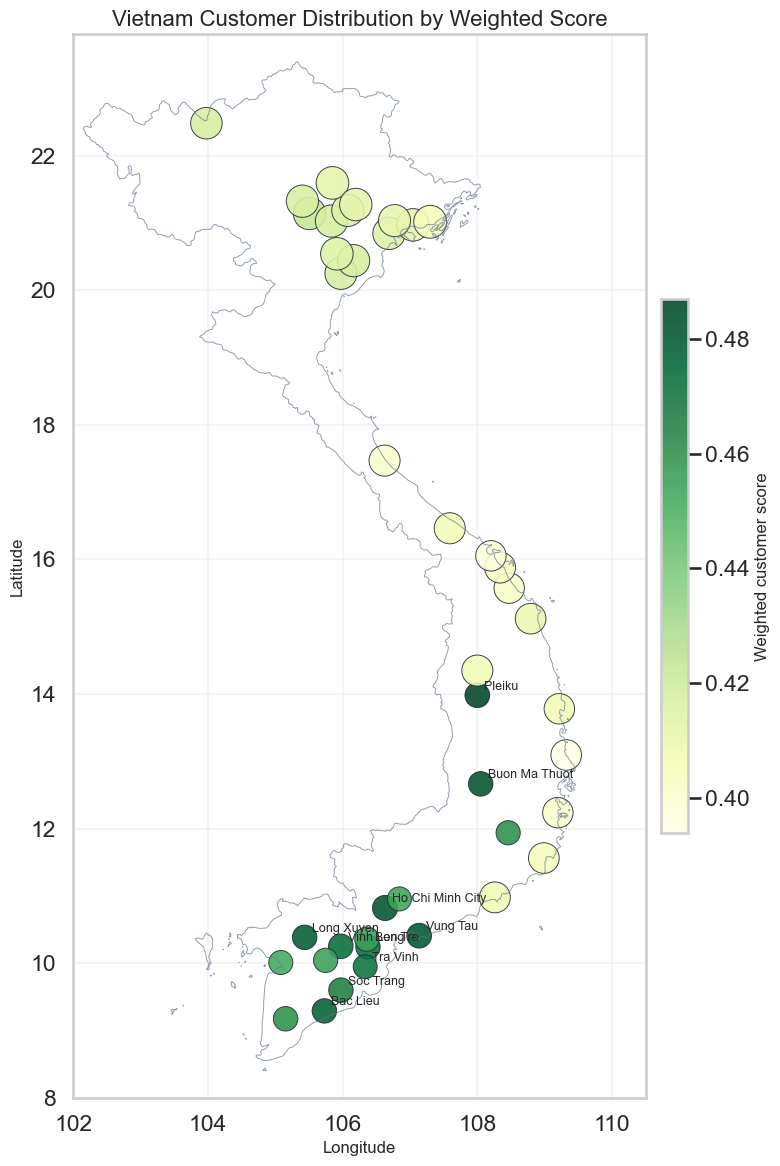

In [13]:
import sys

PROJECT_ROOT = DATA_DIR.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eda import (
    DEFAULT_FEATURE_WEIGHTS,
    build_city_nodes,
    create_customer_distribution_map,
    load_customer_distribution_inputs,
)

boundary_shapefile = (
    DATA_DIR
    / 'truong.le'
    / 'vn_boundary'
    / 'extracted_files'
    / 'vietnam_Vietnam_Country_Boundary.shp'
)

customer_map_weights = {
    **DEFAULT_FEATURE_WEIGHTS,
    'profit': 0.32,
    'frequency': 0.18,
    'retention': 0.16,
    'units': 0.14,
    'refund': -0.05,
    'return_qty': -0.03,
}

customer_map_df, boundary_shapefile = load_customer_distribution_inputs(project_root=PROJECT_ROOT)
customer_city_nodes = build_city_nodes(customer_map_df, feature_weights=customer_map_weights)
display(customer_city_nodes.head(10))

customer_distribution_map = create_customer_distribution_map(
    customer_map_df,
    boundary_shapefile=boundary_shapefile,
    feature_weights=customer_map_weights,
    prefer_interactive=True,
)

## 4. The Problem: Profit Concentrated in a Few Customers

If profit is concentrated in a small percentage of customers, a "spread-out" marketing strategy will waste budget. The Lorenz Curve is the most visual way to demonstrate this imbalance.

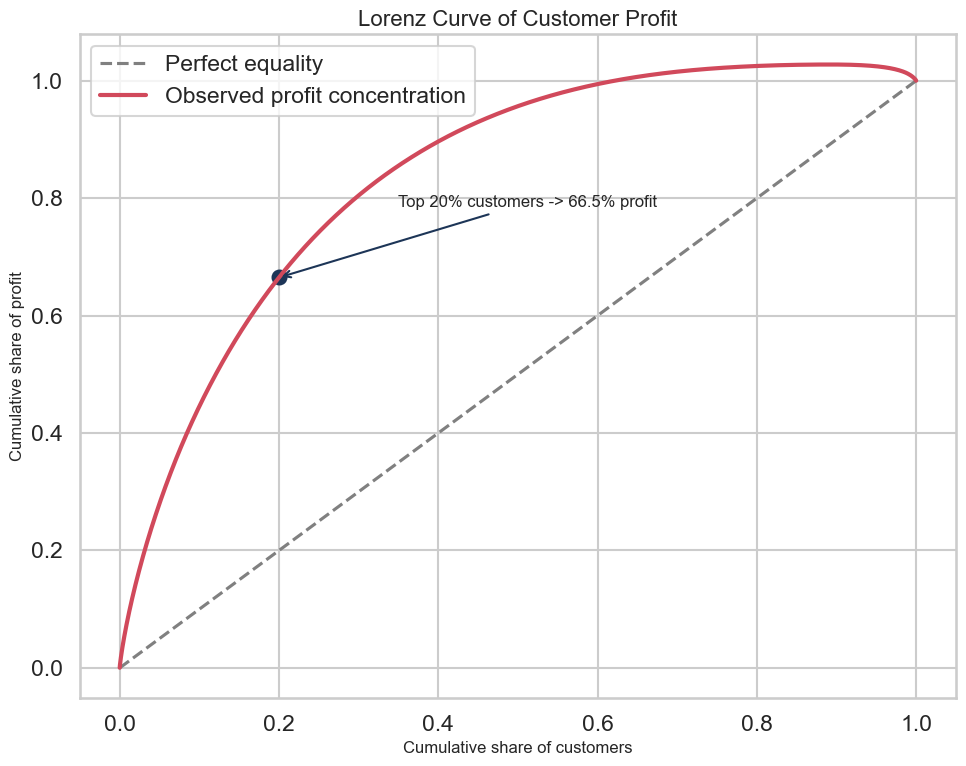

**Key Insight:** Top 10% of customers bring in **44.5%** profit; Top 20% bring in **66.5%**; top 30% have accounted for **80.5%**. This confirms that the business should not spend its marketing budget indiscriminately.

In [14]:
pareto = customer_golden_table.sort_values('monetary_profit', ascending=False).reset_index(drop=True)
pareto['cum_customer_pct'] = (pareto.index + 1) / len(pareto)
pareto['cum_profit_pct'] = pareto['monetary_profit'].cumsum() / pareto['monetary_profit'].sum()

top10_share = pareto.loc[pareto['cum_customer_pct'] <= 0.10, 'monetary_profit'].sum() / pareto['monetary_profit'].sum()
top20_share = pareto.loc[pareto['cum_customer_pct'] <= 0.20, 'monetary_profit'].sum() / pareto['monetary_profit'].sum()
top30_share = pareto.loc[pareto['cum_customer_pct'] <= 0.30, 'monetary_profit'].sum() / pareto['monetary_profit'].sum()

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect equality')
ax.plot(pareto['cum_customer_pct'], pareto['cum_profit_pct'], color='#d1495b', linewidth=3, label='Observed profit concentration')
ax.scatter([0.2], [top20_share], color='#1d3557', s=100)
ax.annotate(
    f'Top 20% customers -> {pct(top20_share)} profit',
    xy=(0.2, top20_share),
    xytext=(0.35, min(top20_share + 0.12, 0.95)),
    arrowprops={'arrowstyle': '->', 'color': '#1d3557'},
    fontsize=12,
)
ax.set_title('Lorenz Curve of Customer Profit')
ax.set_xlabel('Cumulative share of customers')
ax.set_ylabel('Cumulative share of profit')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

display(Markdown(
    f'**Key Insight:** Top 10% of customers bring in **{pct(top10_share)}** profit; '
    f'Top 20% bring in **{pct(top20_share)}**; top 30% have accounted for **{pct(top30_share)}**. '
    'This confirms that the business should not spend its marketing budget indiscriminately.'
))

## 5. Analysis: RFM Segmentation, Objective Score & KMeans Diagnostic

We keep the explainable rule-based RFM segmentation, then add an objective-weighted score and a KMeans diagnostic layer.

The RFM rule uses 3 axes:
- **Recency:** Customers who have purchased more recently will have higher scores.
- **Frequency:** Customers who make repeat purchases will have higher scores.
- **Monetary:** **profit** is used instead of **revenue** to stay focused on business goals.

After scoring according to quintile (1-5), customers are mapped into 6 operational groups: `Champions`, `Loyal`, `Potential`, `Need Attention`, `At Risk`, `Lost`.

The objective score then combines profit, frequency, retention, margin, relationship lifespan, satisfaction, review engagement, promotion usage, refund amount, refund rate, and return quantity. Score tiers are assigned with the same distribution as the initial RFM labels, then averaged with RFM tiers into one final six-label segmentation. Finally, KMeans is run with `k=len(final_segment_order)` to check whether the final labels align with natural behavior clusters in this dataset.


**Initial RFM behavior labels:** R/F/M scores are quintiles computed from the current customer base, so thresholds such as `>= 4` mean top 40% within this dataset, not a generic external rule. `Champions`, `Loyal`, `Potential`, `Need Attention`, `At Risk`, and `Lost` form the six-label business vocabulary.

,segment,customers,avg_profit,total_profit,avg_frequency,avg_recency,avg_aov,avg_margin,promo_usage,avg_lifespan,avg_rating,avg_review_count,refund_rate,avg_objective_score,customer_share,profit_share
0,Champions,20598,68907.0,1.419348e+09,17.77,260.0,26802.0,0.156,0.369,3316.0,3.95,3.17,0.031,0.643,0.229,0.633
1,Loyal,12357,34290.0,4.237253e+08,10.21,1018.0,24337.0,0.143,0.377,2484.0,3.94,1.80,0.032,0.524,0.137,0.189
2,Potential,11886,8591.0,1.021150e+08,4.13,329.0,27594.0,0.111,0.400,2280.0,3.97,0.71,0.034,0.487,0.132,0.046
3,Need Attention,11982,7846.0,9.400918e+07,2.89,1010.0,25757.0,0.109,0.424,1329.0,3.98,0.52,0.033,0.437,0.133,0.042
4,At Risk,7585,11413.0,8.656871e+07,3.89,1994.0,22957.0,0.131,0.381,1287.0,3.97,0.70,0.034,0.407,0.084,0.039
5,Lost,25580,4530.0,1.158782e+08,1.34,2517.0,23538.0,0.138,0.370,237.0,3.99,0.24,0.035,0.352,0.284,0.052


**Objective score tiers with the same distribution:** `objective_score` combines profit, frequency, retention, margin, relationship lifespan, satisfaction, review engagement, promotion usage, refund amount, refund rate, and return quantity. Customers are sorted by this score, then assigned to the same six labels using the exact customer counts from the RFM distribution. This makes score tiers comparable with RFM tiers without creating extra segment names.

,score_segment,customers,avg_profit,total_profit,avg_frequency,avg_recency,avg_aov,avg_margin,promo_usage,avg_lifespan,avg_rating,avg_review_count,refund_rate,avg_objective_score,customer_share,profit_share
0,Champions,20598,74162.0,1.527593e+09,18.15,336.0,27450.0,0.170,0.341,3257.0,3.98,3.29,0.021,0.656,0.229,0.681
1,Loyal,12357,26233.0,3.241649e+08,7.83,577.0,26795.0,0.164,0.329,2738.0,3.97,1.36,0.023,0.533,0.137,0.145
2,Potential,11886,15350.0,1.824560e+08,5.20,851.0,26365.0,0.160,0.322,2074.0,3.97,0.89,0.025,0.485,0.132,0.081
3,Need Attention,11982,9637.0,1.154710e+08,3.61,1272.0,25530.0,0.156,0.304,1394.0,3.95,0.62,0.029,0.443,0.133,0.052
4,At Risk,7585,6451.0,4.892806e+07,2.67,1708.0,24831.0,0.152,0.304,900.0,3.96,0.47,0.029,0.409,0.084,0.022
5,Lost,25580,1682.0,4.303182e+07,1.71,2389.0,21950.0,0.065,0.530,343.0,3.95,0.29,0.055,0.334,0.284,0.019


**Final segment = averaged RFM tier and score tier:** RFM label gives `rfm_tier` and objective-score label gives `score_tier`, where `Champions=1` and `Lost=6`. The final tier is `floor((rfm_tier + score_tier) / 2)`, so a `Champions` customer with score tier 2 remains `Champions`, while score tier 3 moves to `Loyal`. This keeps the final segmentation compact and explainable while still allowing the objective score to adjust priority.

,final_segment,customers,avg_profit,total_profit,avg_frequency,avg_recency,avg_aov,avg_margin,promo_usage,avg_lifespan,avg_rating,avg_review_count,refund_rate,avg_objective_score,customer_share,profit_share
0,Champions,22765,69719.0,1.587162e+09,17.65,335.0,26789.0,0.160,0.361,3252.0,3.96,3.17,0.026,0.643,0.253,0.708
1,Loyal,12547,24795.0,3.110995e+08,7.61,686.0,26269.0,0.158,0.335,2640.0,3.97,1.32,0.025,0.523,0.139,0.139
2,Potential,12246,11103.0,1.359716e+08,4.39,733.0,26624.0,0.139,0.353,2010.0,3.95,0.76,0.031,0.475,0.136,0.061
3,Need Attention,10057,8935.0,8.986326e+07,3.25,1242.0,25687.0,0.130,0.363,1365.0,3.97,0.57,0.036,0.435,0.112,0.040
4,At Risk,13394,5511.0,7.381700e+07,2.38,1834.0,24774.0,0.130,0.379,710.0,3.97,0.42,0.036,0.391,0.149,0.033
5,Lost,18979,2304.0,4.373051e+07,1.27,2698.0,21602.0,0.092,0.472,151.0,3.97,0.23,0.045,0.326,0.211,0.020


**KMeans diagnostic:** KMeans is run with `k=len(final_segment_order)=6` to compare six natural behavior clusters against the six final labels. The sampled silhouette score is **0.195**, so this remains a diagnostic view rather than a replacement for explainable business rules.

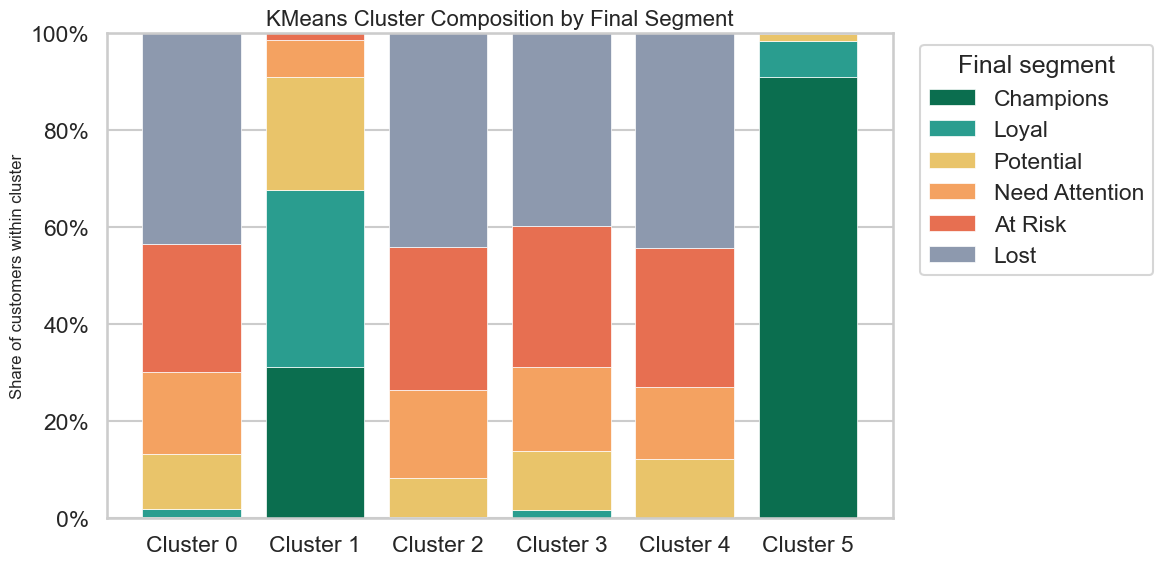

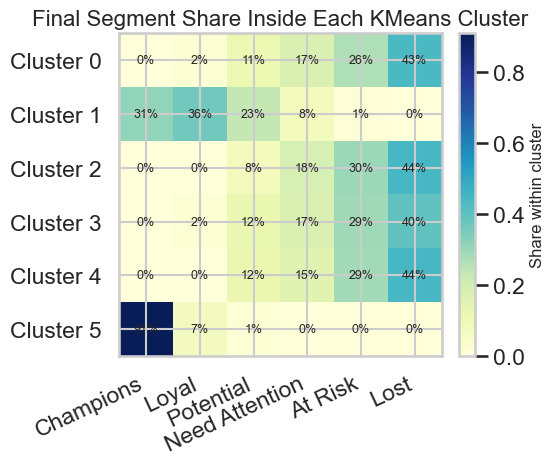

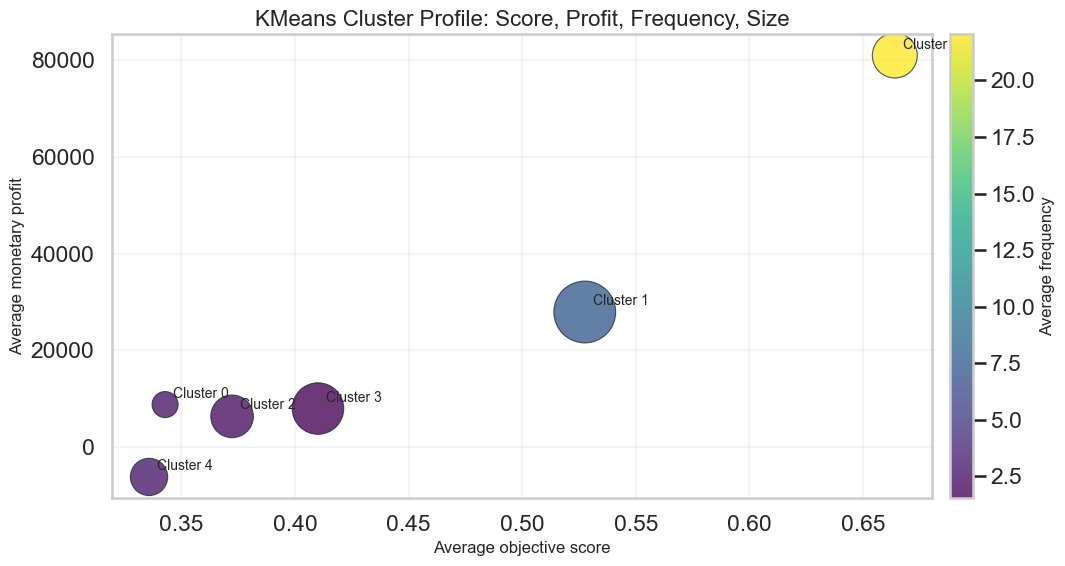

**Cluster profile table:** Use this after the charts to inspect the numeric drivers behind each cluster.

,customers,avg_recency,avg_frequency,avg_profit,avg_margin,promo_usage,refund_rate,return_qty,avg_lifespan,avg_rating,avg_review_count,avg_score,customer_share
kmeans_cluster,,,,,,,,,,,,,
0,2897,1741.283,2.597,8739.684,0.145,0.367,0.516,4.630,992.001,3.991,0.256,0.343,0.032
1,30369,718.342,7.437,27904.222,0.153,0.355,0.020,0.782,2643.426,3.955,1.197,0.528,0.337
2,12833,1895.227,2.202,6299.397,0.160,0.731,0.007,0.131,763.640,3.970,0.396,0.372,0.143
3,20144,2144.125,1.543,7914.756,0.208,0.018,0.004,0.057,341.511,3.991,0.265,0.410,0.224
4,9111,1620.794,2.688,-6244.432,-0.144,0.799,0.012,0.281,987.542,3.973,0.479,0.336,0.101
5,14634,296.464,22.036,81011.353,0.144,0.380,0.042,4.579,3350.716,3.940,4.215,0.664,0.163


**Cluster explanation table:** Dominant and minority final labels are interpreted from each cluster profile relative to the overall cluster median.

,kmeans_cluster,dominant_segment,dominant_share,smallest_segment,smallest_share,explanation
0,0,Lost,0.434933,Champions,0.001381,Lost dominates because this cluster shows belo...
1,1,Loyal,0.364681,Lost,0.000099,Loyal dominates because this cluster shows abo...
2,2,Lost,0.441830,Champions,0.000000,Lost dominates because this cluster shows belo...
3,3,Lost,0.397141,Champions,0.000000,Lost dominates because this cluster shows abov...
4,4,Lost,0.444079,Loyal,0.000000,Lost dominates because this cluster shows belo...
5,5,Champions,0.909936,Lost,0.000000,Champions dominates because this cluster shows...


In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = DATA_DIR.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eda import (
    DEFAULT_OBJECTIVE_WEIGHTS,
    FINAL_SEGMENT_ORDER,
    SEGMENT_LABELS,
    SEGMENT_ORDER,
    apply_objective_rfm_workflow,
    plot_kmeans_cluster_profile,
    plot_kmeans_segment_distribution,
    plot_kmeans_segment_heatmap,
)

objective_weights = {
    **DEFAULT_OBJECTIVE_WEIGHTS,
    # Balanced objective: value and LTV are primary; promo, refund, and returns are cost/leakage penalties.
    'profit': 0.32,
    'frequency': 0.18,
    'retention': 0.18,
    'margin': 0.10,
    'lifespan': 0.07,
    'satisfaction': 0.03,
    'review_engagement': 0.02,
    'promo': -0.08,
    'refund': -0.08,
    'refund_rate': -0.05,
    'return_qty': -0.04,
}

segment_labels = SEGMENT_LABELS
final_segment_order = FINAL_SEGMENT_ORDER
segmentation_result = apply_objective_rfm_workflow(
    customer_golden_table,
    weights=objective_weights,
    segment_labels=segment_labels,
    n_clusters=len(final_segment_order),
)

customer_golden_table = segmentation_result.customer_table
segment_order = SEGMENT_ORDER
segment_summary = segmentation_result.segment_summary
score_segment_summary = segmentation_result.score_segment_summary
final_segment_summary = segmentation_result.final_segment_summary
cluster_profile = segmentation_result.cluster_profile
cluster_segment_distribution = segmentation_result.cluster_segment_distribution
cluster_explanations = segmentation_result.cluster_explanations
kmeans_silhouette = segmentation_result.silhouette

def format_segment_summary(summary):
    rounded = summary.reset_index().copy()
    round_specs = {
        'avg_profit': 0,
        'total_profit': 0,
        'avg_frequency': 2,
        'avg_recency': 0,
        'avg_aov': 0,
        'avg_margin': 3,
        'promo_usage': 3,
        'avg_lifespan': 0,
        'avg_rating': 2,
        'avg_review_count': 2,
        'refund_rate': 3,
        'avg_objective_score': 3,
        'customer_share': 3,
        'profit_share': 3,
    }
    for col, digits in round_specs.items():
        if col in rounded.columns:
            rounded[col] = rounded[col].round(digits)
    return rounded

segment_summary_round = format_segment_summary(segment_summary)
score_segment_summary_round = format_segment_summary(score_segment_summary)
final_segment_summary_round = format_segment_summary(final_segment_summary)

silhouette_text = 'not available' if kmeans_silhouette is None else f'{kmeans_silhouette:.3f}'

display(Markdown(
    '**Initial RFM behavior labels:** R/F/M scores are quintiles computed from the current customer base, '
    'so thresholds such as `>= 4` mean top 40% within this dataset, not a generic external rule. '
    '`Champions`, `Loyal`, `Potential`, `Need Attention`, `At Risk`, and `Lost` form the six-label business vocabulary.'
))
display(segment_summary_round)

display(Markdown(
    '**Objective score tiers with the same distribution:** `objective_score` combines profit, frequency, retention, margin, relationship lifespan, satisfaction, review engagement, promotion usage, refund amount, refund rate, and return quantity. '
    'Customers are sorted by this score, then assigned to the same six labels using the exact customer counts from the RFM distribution. '
    'This makes score tiers comparable with RFM tiers without creating extra segment names.'
))
display(score_segment_summary_round)

display(Markdown(
    '**Final segment = averaged RFM tier and score tier:** RFM label gives `rfm_tier` and objective-score label gives `score_tier`, where `Champions=1` and `Lost=6`. '
    'The final tier is `floor((rfm_tier + score_tier) / 2)`, so a `Champions` customer with score tier 2 remains `Champions`, while score tier 3 moves to `Loyal`. '
    'This keeps the final segmentation compact and explainable while still allowing the objective score to adjust priority.'
))
display(final_segment_summary_round)

display(Markdown(
    f'**KMeans diagnostic:** KMeans is run with `k=len(final_segment_order)={len(final_segment_order)}` to compare six natural behavior clusters against the six final labels. '
    f'The sampled silhouette score is **{silhouette_text}**, so this remains a diagnostic view rather than a replacement for explainable business rules.'
))
plot_kmeans_segment_distribution(cluster_segment_distribution, segment_order=final_segment_order)
plt.show()
plot_kmeans_segment_heatmap(cluster_segment_distribution, segment_order=final_segment_order, figsize=(10, 5))
plt.show()
plot_kmeans_cluster_profile(cluster_profile)
plt.show()

display(Markdown('**Cluster profile table:** Use this after the charts to inspect the numeric drivers behind each cluster.'))
display(cluster_profile.round(3))

display(Markdown('**Cluster explanation table:** Dominant and minority final labels are interpreted from each cluster profile relative to the overall cluster median.'))
display(cluster_explanations)





In [16]:
segment_tier_to_label = {
    1: 'Champions',
    2: 'Loyal',
    3: 'Potential',
    4: 'Need Attention',
    5: 'At Risk',
    6: 'Lost',
}

# Always export from the clean golden table, not the enriched analysis table.
clean_customer_golden_table = pd.read_csv(DATA_DIR / 'truong.le/customer_golden_table.csv')

segment_lookup = (
    segmentation_result.customer_table[['customer_id', 'final_tier']]
    .drop_duplicates('customer_id')
    .rename(columns={'final_tier': 'segment_tier'})
)
segment_lookup['segment_tier'] = segment_lookup['segment_tier'].astype(int)
segment_lookup['segment_label'] = segment_lookup['segment_tier'].map(segment_tier_to_label)

customer_golden_table_with_segments = clean_customer_golden_table.merge(
    segment_lookup,
    on='customer_id',
    how='left',
)

missing_segments = customer_golden_table_with_segments['segment_label'].isna().sum()
if missing_segments:
    raise ValueError(f'{missing_segments:,} customers do not have a segment_label.')
if customer_golden_table_with_segments.columns.duplicated().any():
    duplicate_cols = customer_golden_table_with_segments.columns[customer_golden_table_with_segments.columns.duplicated()].tolist()
    raise ValueError(f'Duplicate columns found: {duplicate_cols}')

output_path = DATA_DIR / 'truong.le/customer_golden_table_with_segments.csv'
customer_golden_table_with_segments.to_csv(output_path, index=False)

### Segment Behavior Deep Dive

The final six labels are compact enough for business action, but we still need to understand each segment's behavior: what they buy, where they concentrate, which promotion campaigns reach them, how they pay, which devices they use, and what products receive more reviews.


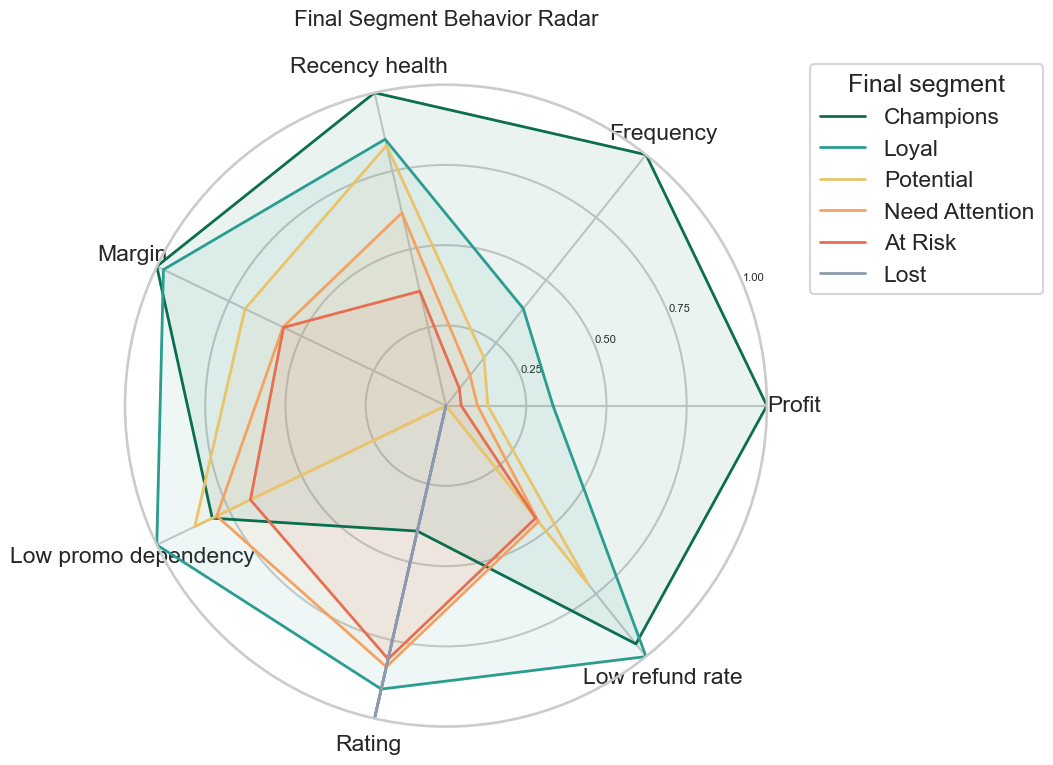

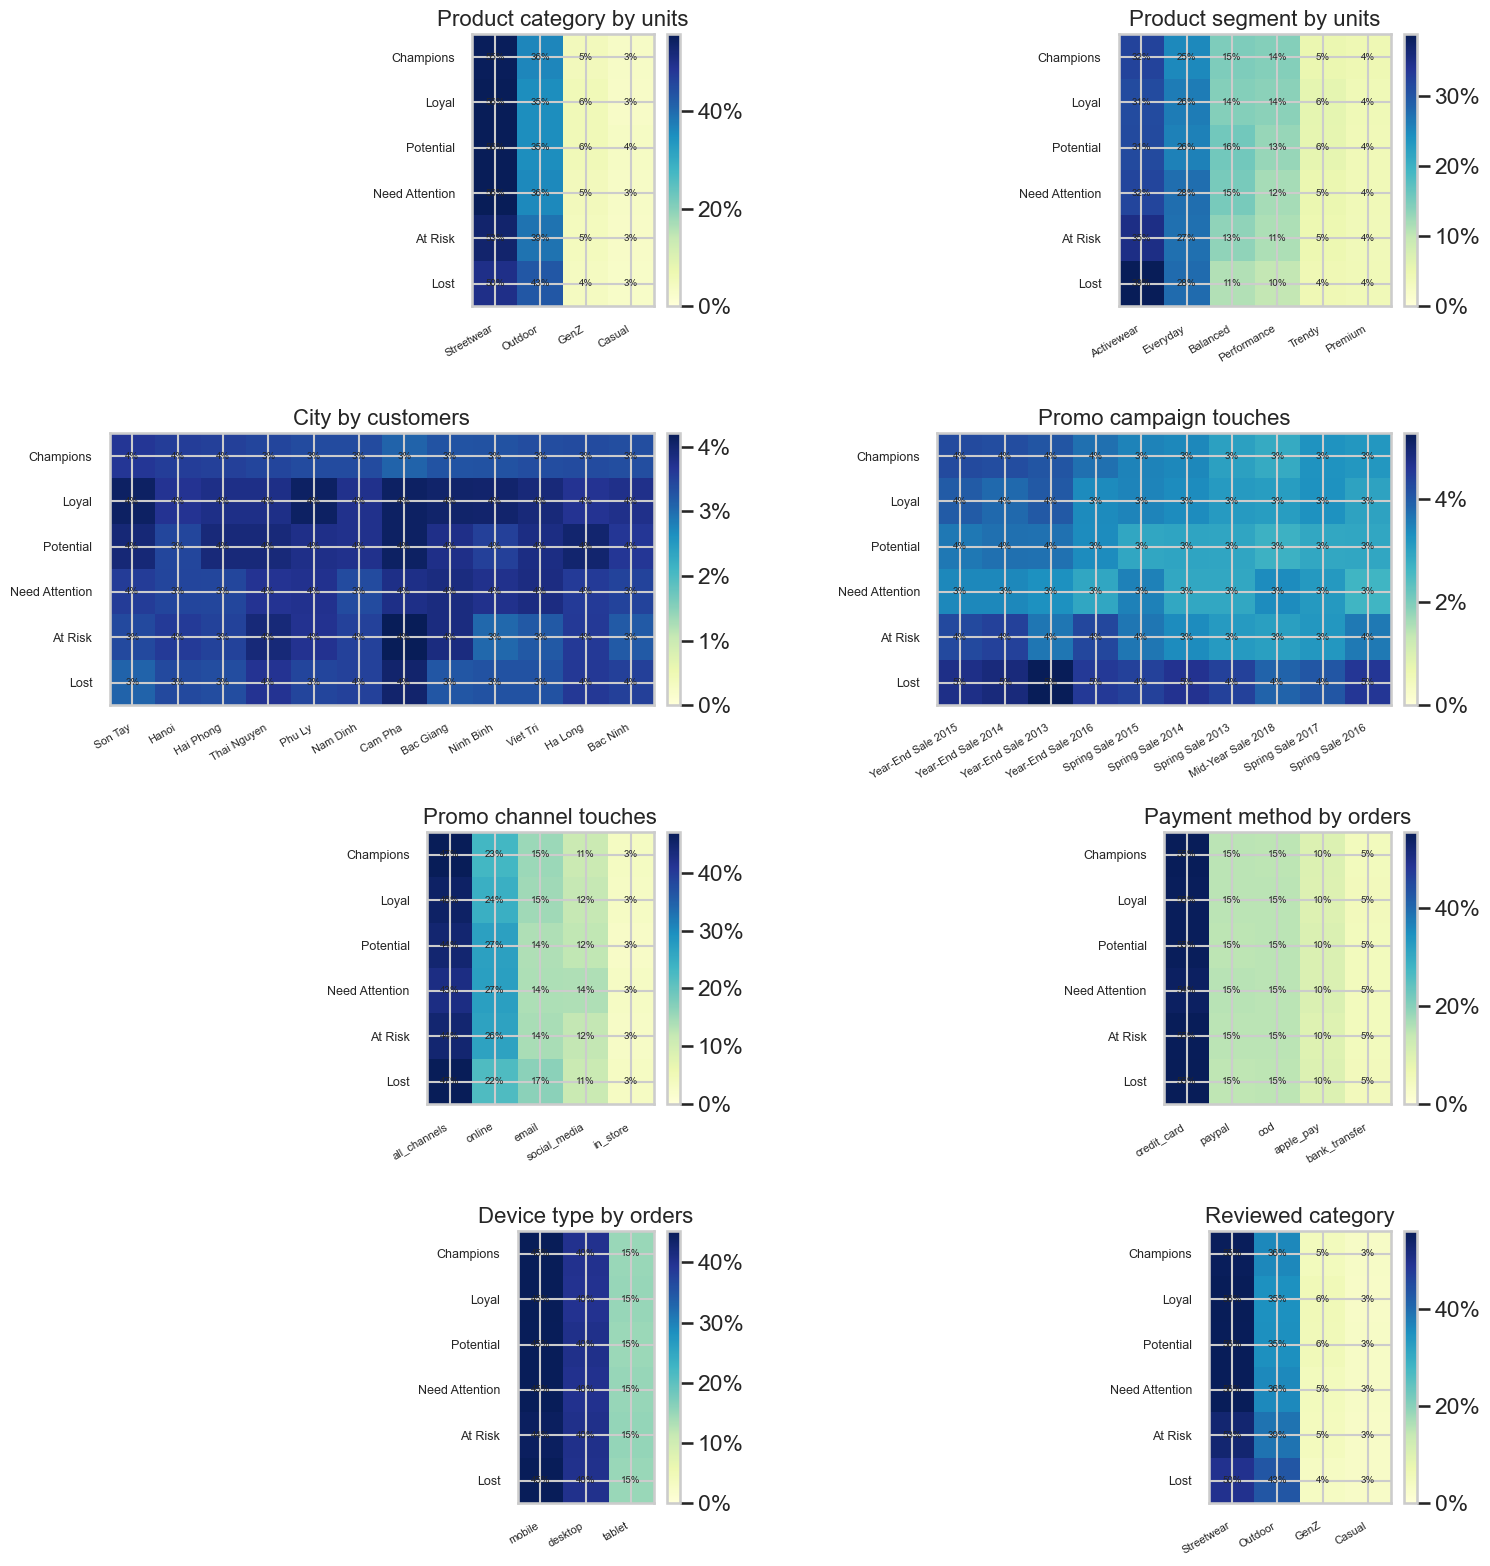

**Top behavior tables:** shares are normalized within each final segment, so these tables show what each label over-indexes on.

**Product category by units**

,final_segment,category,value,share
3,At Risk,Streetwear,84829,0.5325
2,At Risk,Outdoor,61976,0.3890
1,At Risk,GenZ,7587,0.0476
0,At Risk,Casual,4925,0.0309
7,Champions,Streetwear,1122768,0.5521
6,Champions,Outdoor,739273,0.3635
5,Champions,GenZ,103032,0.0507
4,Champions,Casual,68626,0.0337
11,Lost,Streetwear,60386,0.4994
10,Lost,Outdoor,51697,0.4275


**Product segment by units**

,final_segment,product_segment,value,share
0,At Risk,Activewear,55890,0.3508
3,At Risk,Everyday,43518,0.2732
2,At Risk,Balanced,21345,0.1340
4,At Risk,Performance,18109,0.1137
7,At Risk,Trendy,7587,0.0476
8,Champions,Activewear,652632,0.3209
11,Champions,Everyday,506369,0.2490
10,Champions,Balanced,296711,0.1459
12,Champions,Performance,286996,0.1411
15,Champions,Trendy,103032,0.0507


...

,final_segment,acquisition_channel,value,share
2,At Risk,organic_search,3940,0.2942
3,At Risk,paid_search,2699,0.2015
5,At Risk,social_media,2689,0.2008
1,At Risk,email_campaign,1594,0.1190
4,At Risk,referral,1341,0.1001
8,Champions,organic_search,6765,0.2972
11,Champions,social_media,4632,0.2035
9,Champions,paid_search,4608,0.2024
7,Champions,email_campaign,2734,0.1201
10,Champions,referral,2184,0.0959


**Dominant promo type**

,final_segment,dominant_promo_type,value,share
1,At Risk,percentage,6891,0.8774
0,At Risk,fixed,963,0.1226
3,Champions,percentage,21986,0.9803
2,Champions,fixed,441,0.0197
5,Lost,percentage,9300,0.9033
4,Lost,fixed,996,0.0967
7,Loyal,percentage,10272,0.9520
6,Loyal,fixed,518,0.0480
9,Need Attention,percentage,6134,0.9039
8,Need Attention,fixed,652,0.0961


**Order source by orders**

,final_segment,order_source,value,share
2,At Risk,organic_search,9207,0.2852
3,At Risk,paid_search,7054,0.2185
5,At Risk,social_media,6449,0.1998
1,At Risk,email_campaign,3888,0.1204
4,At Risk,referral,3196,0.0990
8,Champions,organic_search,113381,0.2793
9,Champions,paid_search,88943,0.2191
11,Champions,social_media,81722,0.2013
7,Champions,email_campaign,48544,0.1196
10,Champions,referral,40587,0.1000


In [17]:
from eda import (
    build_segment_behavior_profiles,
    plot_segment_behavior_heatmaps,
    plot_segment_radar,
)

behavior_profiles = build_segment_behavior_profiles(
    customer_golden_table,
    data_dir=DATA_DIR,
    segment_col='final_segment',
    segment_order=final_segment_order,
    top_n=6,
)

plot_segment_radar(final_segment_summary, segment_order=final_segment_order)
plt.show()

behavior_chart_names = [
    'Product category by units',
    'Product segment by units',
    'City by customers',
    'Promo campaign touches',
    'Promo channel touches',
    'Payment method by orders',
    'Device type by orders',
    'Reviewed category',
]
plot_segment_behavior_heatmaps(
    behavior_profiles.share_matrices,
    chart_names=behavior_chart_names,
    ncols=2,
    figsize_per_chart=(8, 4),
)
plt.show()

behavior_table_names = behavior_chart_names + [
    'Top products by units',
    'Reviewed products',
    'Acquisition channel',
    'Dominant promo type',
    'Order source by orders',
]

display(Markdown('**Top behavior tables:** shares are normalized within each final segment, so these tables show what each label over-indexes on.'))
for table_name in behavior_table_names:
    if table_name in behavior_profiles.top_tables:
        display(Markdown(f'**{table_name}**'))
        display(behavior_profiles.top_tables[table_name].groupby('final_segment').head(5).round(4))



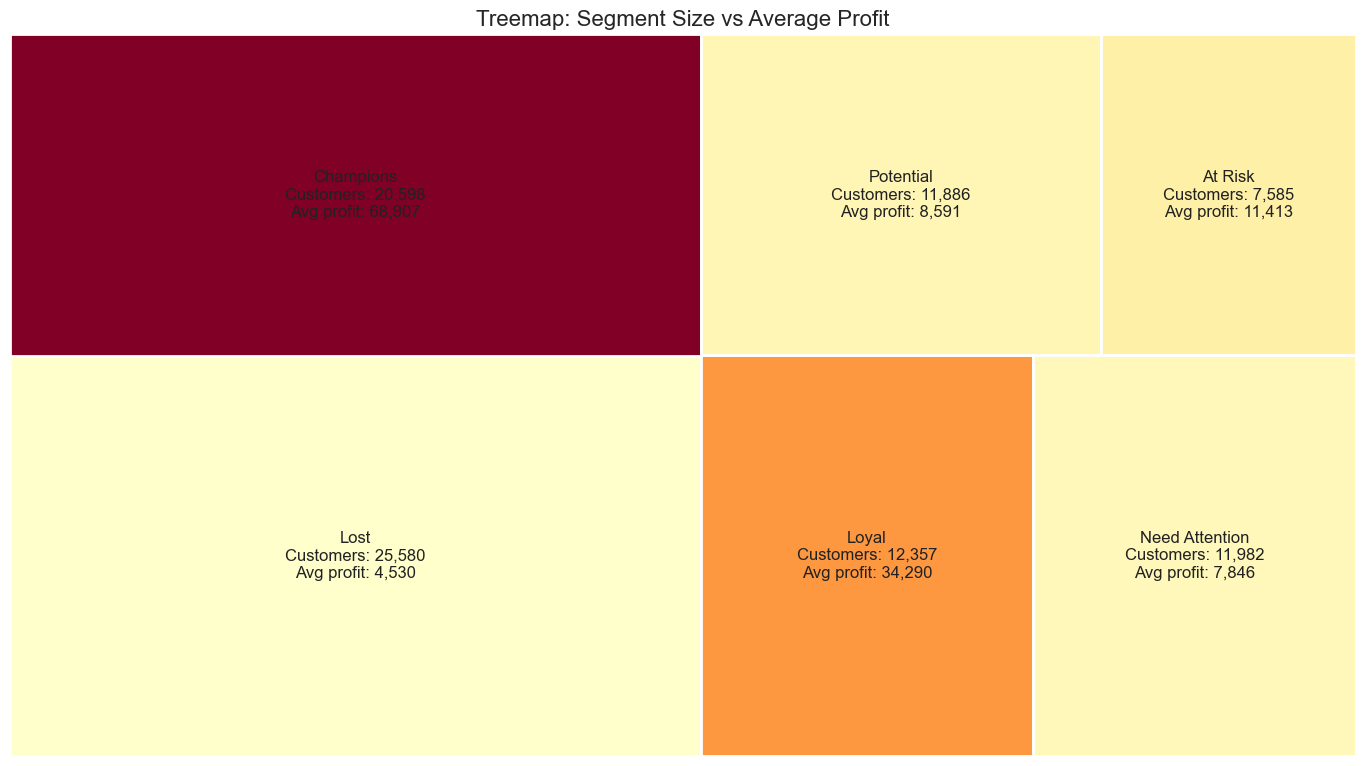

Treemap helps to clearly see the contrast between **segment size** and **average value**:Some large groups do not necessarily generate more profit per customer, while Champions groups often have very high average value.

In [18]:
treemap_df = segment_summary.reset_index()[['segment', 'customers', 'avg_profit']].sort_values('customers', ascending=False).reset_index(drop=True)
rects = binary_treemap(treemap_df['customers'].tolist())
norm = Normalize(vmin=treemap_df['avg_profit'].min(), vmax=treemap_df['avg_profit'].max())
cmap = cm.get_cmap('YlOrRd')

fig, ax = plt.subplots(figsize=(14, 8))
for (_, row), (x, y, w, h) in zip(treemap_df.iterrows(), rects):
    color = cmap(norm(row['avg_profit']))
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor='white', linewidth=2))
    label = (
        f"{row['segment']}\n"
        f"Customers: {int(row['customers']):,}\n"
        f"Avg profit: {fmt_money(row['avg_profit'])}"
    )
    if w * h > 0.06:
        ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=12, color='#222222')
    else:
        ax.text(x + 0.01, y + h / 2, row['segment'], ha='left', va='center', fontsize=10, color='#222222')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Treemap: Segment Size vs Average Profit')
plt.tight_layout()
plt.show()

display(Markdown(
    'Treemap helps to clearly see the contrast between **segment size** and **average value**:'
    'Some large groups do not necessarily generate more profit per customer, while Champions groups often have very high average value.'
))

## 6. Cohort Retention Analysis

A snapshot segmentation tells us who customers are today. Cohort analysis tells us whether the business is getting **better or worse at retaining new customers after their first purchase**.

Because the dataset spans 2012-2022, this section groups cohorts by **first-purchase month of year** (Jan-Dec) instead of `YYYY-MM`. This keeps the heatmap readable and reveals seasonal retention patterns across years. Cancelled orders are excluded because retention should reflect realized purchases only.


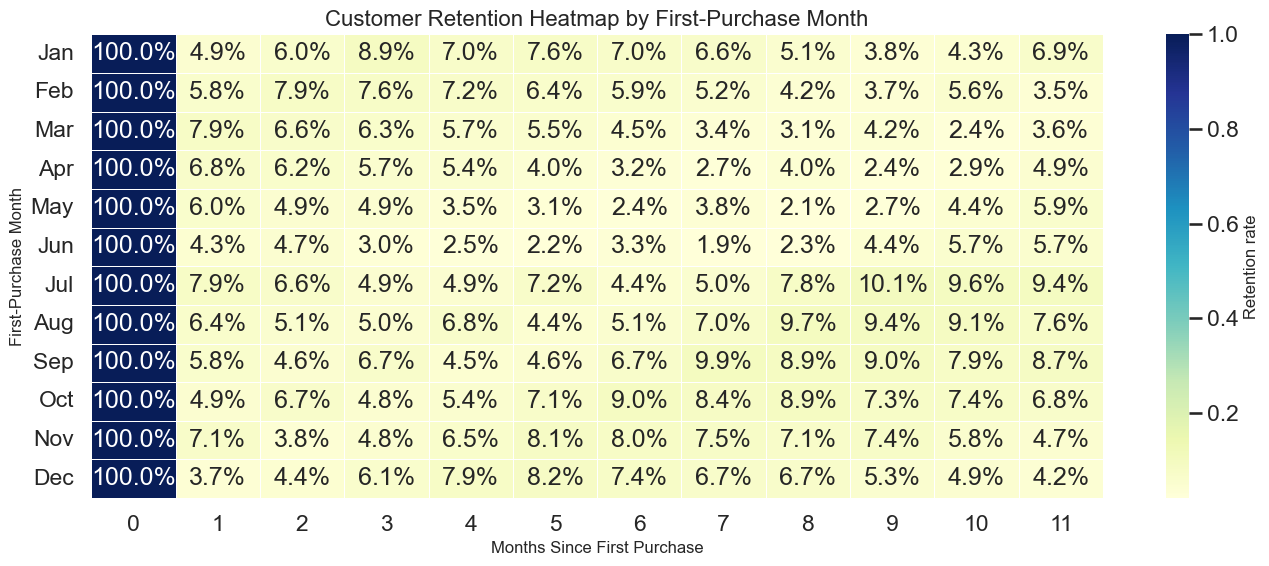

month_number,month_1_retention,month_3_retention
cohort_month,,
Jan,0.0493,0.0894
Feb,0.0585,0.0759
Mar,0.0787,0.0627
Apr,0.0683,0.0568
May,0.0597,0.0489
Jun,0.0434,0.0303
Jul,0.0788,0.0493
Aug,0.0638,0.0497
Sep,0.0578,0.0666


month_number,month_1_retention,month_3_retention
first_order_source,,
referral,0.0597,0.0589
social_media,0.0591,0.0587
email_campaign,0.0617,0.0587
paid_search,0.0606,0.0560
organic_search,0.0578,0.0560
direct,0.0607,0.0551


**Retention readout:** After aggregating cohorts by first-purchase month across 2012-2022, Month-3 retention is highest for **Jan** at **8.9%** and lowest for **Jun** at **3.0%**. The channel mix also matters: customers whose first realized order came from **referral** retain better by month 3 than those coming from **direct**.

In [19]:
retention_orders = orders[orders['order_status'].isin(['paid', 'shipped', 'delivered', 'returned'])].copy()
retention_orders['order_month'] = retention_orders['order_date'].dt.to_period('M')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

cohort_base = (
    retention_orders.groupby('customer_id', as_index=False)['order_date']
    .min()
    .rename(columns={'order_date': 'first_order_date'})
)
cohort_base['cohort_month_period'] = cohort_base['first_order_date'].dt.to_period('M')
cohort_base['cohort_month_number'] = cohort_base['first_order_date'].dt.month
cohort_base['cohort_month'] = cohort_base['first_order_date'].dt.strftime('%b')

cohort_orders = retention_orders.merge(
    cohort_base[['customer_id', 'cohort_month_period', 'cohort_month_number', 'cohort_month']],
    on='customer_id',
    how='left',
)
cohort_orders['month_number'] = (
    cohort_orders['order_month'] - cohort_orders['cohort_month_period']
).apply(lambda x: x.n)

cohort_retention = (
    cohort_orders.groupby(['cohort_month_number', 'cohort_month', 'month_number'])['customer_id']
    .nunique()
    .reset_index(name='customers')
)
cohort_size = (
    cohort_retention[cohort_retention['month_number'] == 0][['cohort_month_number', 'cohort_month', 'customers']]
    .rename(columns={'customers': 'cohort_size'})
)
cohort_retention = cohort_retention.merge(cohort_size, on=['cohort_month_number', 'cohort_month'], how='left')
cohort_retention['retention_rate'] = cohort_retention['customers'] / cohort_retention['cohort_size']

cohort_matrix = (
    cohort_retention
    .pivot(index='cohort_month', columns='month_number', values='retention_rate')
    .reindex(month_order)
)
heatmap_df = cohort_matrix.iloc[:, :12].copy()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_df,
    cmap='YlGnBu',
    annot=True,
    fmt='.1%',
    linewidths=0.5,
    cbar_kws={'label': 'Retention rate'},
    ax=ax,
)
ax.set_title('Customer Retention Heatmap by First-Purchase Month')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('First-Purchase Month')
plt.tight_layout()
plt.show()

month_retention_summary = (
    cohort_retention[cohort_retention['month_number'].isin([1, 3])]
    .pivot(index='cohort_month', columns='month_number', values='retention_rate')
    .reindex(month_order)
    .rename(columns={1: 'month_1_retention', 3: 'month_3_retention'})
)

display(month_retention_summary.round(4))

first_order_source = (
    retention_orders.sort_values(['customer_id', 'order_date', 'order_id'])
    .drop_duplicates('customer_id')[['customer_id', 'order_source']]
    .rename(columns={'order_source': 'first_order_source'})
)
cohort_orders_source = cohort_orders.merge(first_order_source, on='customer_id', how='left')
source_retention = (
    cohort_orders_source.groupby(['first_order_source', 'cohort_month_number', 'cohort_month', 'month_number'])['customer_id']
    .nunique()
    .reset_index(name='customers')
)
source_cohort_size = (
    source_retention[source_retention['month_number'] == 0][['first_order_source', 'cohort_month_number', 'cohort_month', 'customers']]
    .rename(columns={'customers': 'cohort_size'})
)
source_retention = source_retention.merge(
    source_cohort_size,
    on=['first_order_source', 'cohort_month_number', 'cohort_month'],
    how='left',
)
source_retention['retention_rate'] = source_retention['customers'] / source_retention['cohort_size']
source_retention_summary = (
    source_retention[source_retention['month_number'].isin([1, 3])]
    .groupby(['first_order_source', 'month_number'])['retention_rate']
    .mean()
    .unstack()
    .rename(columns={1: 'month_1_retention', 3: 'month_3_retention'})
    .sort_values('month_3_retention', ascending=False)
)

display(source_retention_summary.round(4))

best_month = month_retention_summary['month_3_retention'].idxmax()
weakest_month = month_retention_summary['month_3_retention'].idxmin()
display(Markdown(
    f"**Retention readout:** After aggregating cohorts by first-purchase month across 2012-2022, Month-3 retention is highest for **{best_month}** "
    f"at **{pct(month_retention_summary.loc[best_month, 'month_3_retention'])}** and lowest for **{weakest_month}** "
    f"at **{pct(month_retention_summary.loc[weakest_month, 'month_3_retention'])}**. The channel mix also matters: customers whose first realized order came from "
    f"**{source_retention_summary.index[0]}** retain better by month 3 than those coming from **{source_retention_summary.index[-1]}**."
))


## 7. Early Loyalty Propensity Modeling

The goal here is not to build a perfect classifier. The goal is to identify **which early signals available at or shortly after the first order** are associated with future loyalty.

Target definition:
- `is_loyal = 1` if the customer eventually places more than 3 orders
- `is_loyal = 0` otherwise

Feature rationale:
- **Acquisition and first-order channel** (`acquisition_channel`, `first_order_source`) capture the quality of customer acquisition before any repeat behavior is known.
- **Device, payment, installments, region, and city** capture early purchase context and friction: payment flexibility, device behavior, and market-level geography can shape whether customers come back.
- **First basket economics** (`first_order_value`, `first_order_profit`, `first_order_margin`, `first_order_discount_rate`, `first_order_units`, `first_order_item_count`) capture whether the first purchase is valuable, margin-positive, or discount-dependent.
- **First product signal** (`first_product_category`, `first_product_segment`, `first_product_price_band`) captures initial intent: different entry products can attract different loyalty profiles.
- **Early service and feedback signals** (`first_delivery_days`, `first_shipping_fee`, `first_order_return_qty`, `first_order_refund`, `has_first_order_review`, `first_order_rating`) capture post-purchase experience without using future repeat orders.
- **Timing and relationship setup** (`first_order_month`, `signup_to_first_order_days`) capture seasonality and how quickly a signup converts into a first purchase.

Implementation note: the model intentionally avoids anonymous `district` codes because they can dominate coefficients without creating clear business insight; `city` and `region` are more interpretable for market-level action.


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

geography = pd.read_csv(DATA_DIR / 'geography.csv')
payments = pd.read_csv(DATA_DIR / 'payments.csv')
shipments = pd.read_csv(DATA_DIR / 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv(DATA_DIR / 'returns.csv')
reviews = pd.read_csv(DATA_DIR / 'reviews.csv', parse_dates=['review_date'])

realized_orders = orders[orders['order_status'].isin(['paid', 'shipped', 'delivered', 'returned'])].copy()
realized_orders['order_date'] = pd.to_datetime(realized_orders['order_date'], errors='coerce')
realized_item_facts = item_facts[item_facts['order_id'].isin(realized_orders['order_id'])].copy()

if 'segment' not in realized_item_facts.columns:
    realized_item_facts = realized_item_facts.merge(
        products[['product_id', 'segment']].drop_duplicates('product_id'),
        on='product_id',
        how='left',
    )

first_orders = (
    realized_orders.sort_values(['customer_id', 'order_date', 'order_id'])
    .drop_duplicates('customer_id')[['customer_id', 'order_id', 'order_date', 'zip', 'device_type', 'order_source', 'payment_method']]
    .rename(columns={
        'order_id': 'first_order_id',
        'order_date': 'first_order_date',
        'zip': 'first_order_zip',
        'order_source': 'first_order_source',
        'payment_method': 'first_payment_method',
    })
)
first_orders = first_orders.merge(
    geography[['zip', 'city', 'region']].drop_duplicates('zip'),
    left_on='first_order_zip',
    right_on='zip',
    how='left',
).drop(columns='zip').rename(columns={'city': 'first_order_city'})
first_orders['first_order_month'] = first_orders['first_order_date'].dt.month_name().str.slice(stop=3)

first_order_items = realized_item_facts.merge(
    first_orders[['customer_id', 'first_order_id']],
    left_on=['customer_id', 'order_id'],
    right_on=['customer_id', 'first_order_id'],
    how='inner',
)
first_order_basket = (
    first_order_items.groupby(['customer_id', 'first_order_id'], as_index=False)
    .agg(
        first_order_value=('line_revenue', 'sum'),
        first_order_profit=('line_profit', 'sum'),
        first_order_units=('quantity', 'sum'),
        first_order_item_count=('product_id', 'nunique'),
        first_order_discount=('discount_amount', 'sum'),
        is_promo_first_order=('used_promo', 'max'),
    )
)
first_order_basket['first_order_margin'] = first_order_basket['first_order_profit'] / first_order_basket['first_order_value'].replace(0, np.nan)
first_order_basket['first_order_discount_rate'] = first_order_basket['first_order_discount'] / (
    first_order_basket['first_order_value'] + first_order_basket['first_order_discount']
).replace(0, np.nan)

first_order_primary_product = (
    first_order_items.sort_values(
        ['customer_id', 'order_date', 'order_id', 'line_revenue'],
        ascending=[True, True, True, False],
    )
    .drop_duplicates('customer_id')[[
        'customer_id',
        'category',
        'segment',
        'unit_price',
        'cogs',
    ]]
    .rename(columns={
        'category': 'first_product_category',
        'segment': 'first_product_segment',
        'unit_price': 'first_product_unit_price',
        'cogs': 'first_product_cogs',
    })
)
first_order_primary_product['first_product_price_band'] = pd.qcut(
    first_order_primary_product['first_product_unit_price'].rank(method='first'),
    q=4,
    labels=['Low', 'Mid', 'High', 'Premium'],
)

first_payment = (
    payments.sort_values(['order_id'])
    .groupby('order_id', as_index=False)
    .agg(
        first_payment_value=('payment_value', 'sum'),
        first_installments=('installments', 'max'),
    )
    .rename(columns={'order_id': 'first_order_id'})
)

first_shipping = shipments.rename(columns={'order_id': 'first_order_id'}).copy()
first_shipping['first_delivery_days'] = (
    first_shipping['delivery_date'] - first_shipping['ship_date']
).dt.days
first_shipping = first_shipping[['first_order_id', 'shipping_fee', 'first_delivery_days']].rename(
    columns={'shipping_fee': 'first_shipping_fee'}
)

first_returns = (
    returns.rename(columns={'order_id': 'first_order_id'})
    .groupby('first_order_id', as_index=False)
    .agg(
        first_order_return_qty=('return_quantity', 'sum'),
        first_order_refund=('refund_amount', 'sum'),
    )
)

first_reviews = (
    reviews.merge(first_orders[['customer_id', 'first_order_id']], left_on=['customer_id', 'order_id'], right_on=['customer_id', 'first_order_id'], how='inner')
    .groupby(['customer_id', 'first_order_id'], as_index=False)
    .agg(
        has_first_order_review=('review_id', 'count'),
        first_order_rating=('rating', 'mean'),
    )
)
first_reviews['has_first_order_review'] = (first_reviews['has_first_order_review'] > 0).astype(int)

loyalty_model_df = customer_golden_table[['customer_id', 'frequency']].copy()
loyalty_model_df['is_loyal'] = (loyalty_model_df['frequency'] > 3).astype(int)
loyalty_model_df = (
    loyalty_model_df
    .merge(customers[['customer_id', 'acquisition_channel', 'signup_date', 'gender', 'age_group']], on='customer_id', how='left')
    .merge(first_orders[['customer_id', 'first_order_id', 'first_order_date', 'device_type', 'first_order_source', 'first_payment_method', 'first_order_city', 'region', 'first_order_month']], on='customer_id', how='left')
    .merge(first_order_basket, on=['customer_id', 'first_order_id'], how='left')
    .merge(first_order_primary_product, on='customer_id', how='left')
    .merge(first_payment, on='first_order_id', how='left')
    .merge(first_shipping, on='first_order_id', how='left')
    .merge(first_returns, on='first_order_id', how='left')
    .merge(first_reviews, on=['customer_id', 'first_order_id'], how='left')
)

loyalty_model_df['signup_date'] = pd.to_datetime(loyalty_model_df['signup_date'], errors='coerce')
loyalty_model_df['signup_to_first_order_days'] = (
    loyalty_model_df['first_order_date'] - loyalty_model_df['signup_date']
).dt.days
loyalty_model_df['signup_to_first_order_days'] = loyalty_model_df['signup_to_first_order_days'].clip(lower=0)
loyalty_model_df['is_promo_first_order'] = loyalty_model_df['is_promo_first_order'].map({True: 'Yes', False: 'No'}).fillna('No')
loyalty_model_df['has_first_order_review'] = loyalty_model_df['has_first_order_review'].fillna(0).astype(int).map({1: 'Yes', 0: 'No'})
loyalty_model_df['first_order_return_qty'] = loyalty_model_df['first_order_return_qty'].fillna(0)
loyalty_model_df['first_order_refund'] = loyalty_model_df['first_order_refund'].fillna(0)
loyalty_model_df['first_order_margin'] = loyalty_model_df['first_order_margin'].replace([np.inf, -np.inf], np.nan)
loyalty_model_df['first_order_discount_rate'] = loyalty_model_df['first_order_discount_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

categorical_features = [
    'acquisition_channel',
    'first_order_source',
    'device_type',
    'first_payment_method',
    'first_order_city',
    'region',
    'gender',
    'age_group',
    'first_order_month',
    'first_product_category',
    'first_product_segment',
    'first_product_price_band',
    'is_promo_first_order',
    'has_first_order_review',
]
numeric_features = [
    'first_order_value',
    'first_order_profit',
    'first_order_margin',
    'first_order_discount_rate',
    'first_order_units',
    'first_order_item_count',
    'first_product_unit_price',
    'first_product_cogs',
    'first_payment_value',
    'first_installments',
    'first_shipping_fee',
    'first_delivery_days',
    'first_order_return_qty',
    'first_order_refund',
    'first_order_rating',
    'signup_to_first_order_days',
]

X = loyalty_model_df[categorical_features + numeric_features].copy()
y = loyalty_model_df['is_loyal']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01)),
            ]),
            categorical_features,
        ),
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_features,
        ),
    ]
)

loyalty_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=3000, class_weight='balanced')),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
loyalty_pipeline.fit(X_train, y_train)
test_proba = loyalty_pipeline.predict_proba(X_test)[:, 1]
loyalty_auc = roc_auc_score(y_test, test_proba)

interpret_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=3000, class_weight='balanced')),
])
interpret_pipeline.fit(X, y)

feature_names = interpret_pipeline.named_steps['preprocessor'].get_feature_names_out()
coef_table = pd.DataFrame({
    'term': feature_names,
    'coef': interpret_pipeline.named_steps['classifier'].coef_[0],
})

def clean_term(term: str) -> str:
    term = term.replace('categorical__', '').replace('numeric__', '')
    prefixes = {
        'acquisition_channel_': 'Acquisition channel: ',
        'first_order_source_': 'First order source: ',
        'device_type_': 'Device: ',
        'first_payment_method_': 'Payment method: ',
        'region_': 'Region: ',
        'first_order_city_': 'First order city: ',
        'gender_': 'Gender: ',
        'age_group_': 'Age group: ',
        'first_order_month_': 'First order month: ',
        'first_product_category_': 'First product category: ',
        'first_product_segment_': 'First product segment: ',
        'first_product_price_band_': 'First product price band: ',
        'is_promo_first_order_': 'Promo on first order: ',
        'has_first_order_review_': 'Reviewed first order: ',
    }
    numeric_labels = {
        'first_order_value': 'First order value',
        'first_order_profit': 'First order profit',
        'first_order_margin': 'First order margin',
        'first_order_discount_rate': 'First order discount rate',
        'first_order_units': 'First order units',
        'first_order_item_count': 'First order item count',
        'first_product_unit_price': 'First product unit price',
        'first_product_cogs': 'First product COGS',
        'first_payment_value': 'First payment value',
        'first_installments': 'First order installments',
        'first_shipping_fee': 'First shipping fee',
        'first_delivery_days': 'First delivery days',
        'first_order_return_qty': 'First order return qty',
        'first_order_refund': 'First order refund',
        'first_order_rating': 'First order rating',
        'signup_to_first_order_days': 'Signup to first order days',
    }
    for prefix, label in prefixes.items():
        if term.startswith(prefix):
            return label + term[len(prefix):]
    return numeric_labels.get(term, term)

coef_table['label'] = coef_table['term'].map(clean_term)
coef_table['abs_coef'] = coef_table['coef'].abs()
coef_plot = coef_table.sort_values('abs_coef', ascending=False).head(18).sort_values('coef')

feature_group_explanation = pd.DataFrame([
    {'feature_group': 'Acquisition/channel', 'features': 'acquisition_channel, first_order_source', 'why_used': 'Measures traffic and acquisition quality before repeat behavior is known.'},
    {'feature_group': 'Purchase context', 'features': 'device_type, payment method, installments, first-order city, region', 'why_used': 'Captures checkout context, payment flexibility, and interpretable market-level geography without relying on opaque district IDs.'},
    {'feature_group': 'First basket economics', 'features': 'value, profit, margin, discount rate, units, item count', 'why_used': 'Tests whether valuable or discount-dependent first purchases predict future loyalty.'},
    {'feature_group': 'Product intent', 'features': 'first category, product segment, price band, unit price, COGS', 'why_used': 'Initial product choice reveals customer intent and price tier at entry.'},
    {'feature_group': 'Post-purchase experience', 'features': 'delivery days, shipping fee, returns, refunds, first review/rating', 'why_used': 'Early service quality and friction can affect whether customers come back.'},
    {'feature_group': 'Timing/setup', 'features': 'first order month, signup-to-first-order days', 'why_used': 'Captures seasonality and conversion speed from signup to first realized purchase.'},
])

display(Markdown(f'**Validation AUC:** {loyalty_auc:.3f}'))
display(Markdown('**Why these features are used:** All inputs are observable at checkout or shortly after the first order, so they help predict loyalty early without using future repeat-purchase information.'))
display(feature_group_explanation)
display(coef_table.sort_values('abs_coef', ascending=False).round(4))
coef_table.sort_values('coef', ascending=True).sort_values('coef').to_csv(DATA_DIR / 'truong.le/loyalty_model_coefficients.csv', index=False)

**Validation AUC:** 0.693

**Why these features are used:** All inputs are observable at checkout or shortly after the first order, so they help predict loyalty early without using future repeat-purchase information.

,feature_group,features,why_used
0,Acquisition/channel,"acquisition_channel, first_order_source",Measures traffic and acquisition quality befor...
1,Purchase context,"device_type, payment method, installments, fir...","Captures checkout context, payment flexibility..."
2,First basket economics,"value, profit, margin, discount rate, units, i...",Tests whether valuable or discount-dependent f...
3,Product intent,"first category, product segment, price band, u...",Initial product choice reveals customer intent...
4,Post-purchase experience,"delivery days, shipping fee, returns, refunds,...",Early service quality and friction can affect ...
5,Timing/setup,"first order month, signup-to-first-order days",Captures seasonality and conversion speed from...


,term,coef,label,abs_coef
115,numeric__signup_to_first_order_days,-0.9963,Signup to first order days,0.9963
26,categorical__first_order_city_Cam Pha,-0.7451,First order city: Cam Pha,0.7451
108,numeric__first_payment_value,0.7287,First payment value,0.7287
100,numeric__first_order_value,-0.7170,First order value,0.7170
76,categorical__first_order_month_May,-0.5435,First order month: May,0.5435
...,...,...,...,...
96,categorical__is_promo_first_order_No,-0.0051,Promo on first order: No,0.0051
47,categorical__first_order_city_Soc Trang,-0.0037,First order city: Soc Trang,0.0037
75,categorical__first_order_month_Mar,0.0035,First order month: Mar,0.0035
3,categorical__acquisition_channel_paid_search,0.0022,Acquisition channel: paid_search,0.0022


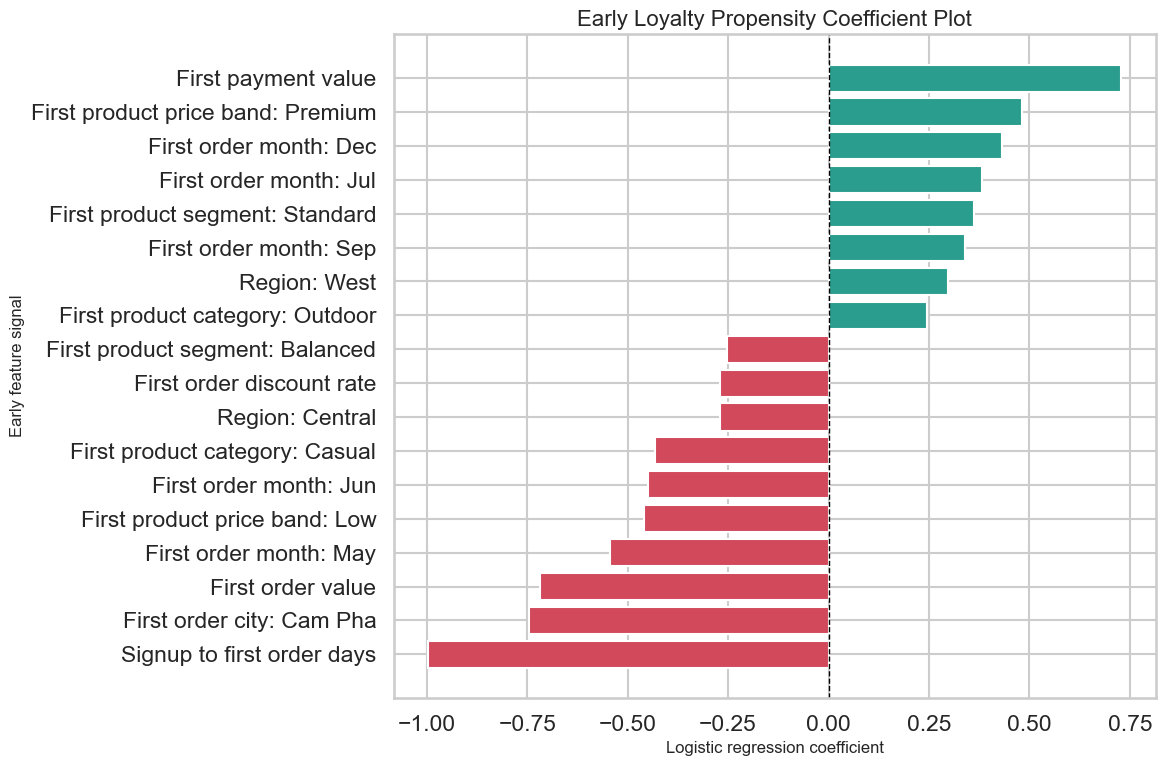

**Model interpretation:** the strongest positive early signal is **First payment value**, while the strongest negative signal is **Signup to first order days**. Because numeric features are standardized and categorical features are one-hot encoded, coefficient direction is useful for interpretation: positive terms increase estimated loyalty propensity and negative terms lower it. Treat the model as an explanatory EDA layer, not a production classifier.

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = ['#d1495b' if coef < 0 else '#2a9d8f' for coef in coef_plot['coef']]
ax.barh(coef_plot['label'], coef_plot['coef'], color=bar_colors)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Early Loyalty Propensity Coefficient Plot')
ax.set_xlabel('Logistic regression coefficient')
ax.set_ylabel('Early feature signal')
plt.tight_layout()
plt.show()

strongest_positive = coef_table.sort_values('coef', ascending=False).iloc[0]
strongest_negative = coef_table.sort_values('coef', ascending=True).iloc[0]

display(Markdown(
    f"**Model interpretation:** the strongest positive early signal is **{strongest_positive['label']}**, while the strongest negative signal is "
    f"**{strongest_negative['label']}**. Because numeric features are standardized and categorical features are one-hot encoded, coefficient direction is useful for interpretation: "
    "positive terms increase estimated loyalty propensity and negative terms lower it. Treat the model as an explanatory EDA layer, not a production classifier."
))


## 8. Promotion Efficiency and Margin Leakage

A strong segmentation story should also explain **why profit is leaking**. In this dataset, promotions are an obvious candidate: they may accelerate conversion, but they can also compress margin so hard that revenue growth does not translate into value creation.

This section answers two questions:
- Which customer segments are the most promo-dependent?
- In which categories do promotions create the largest margin erosion?

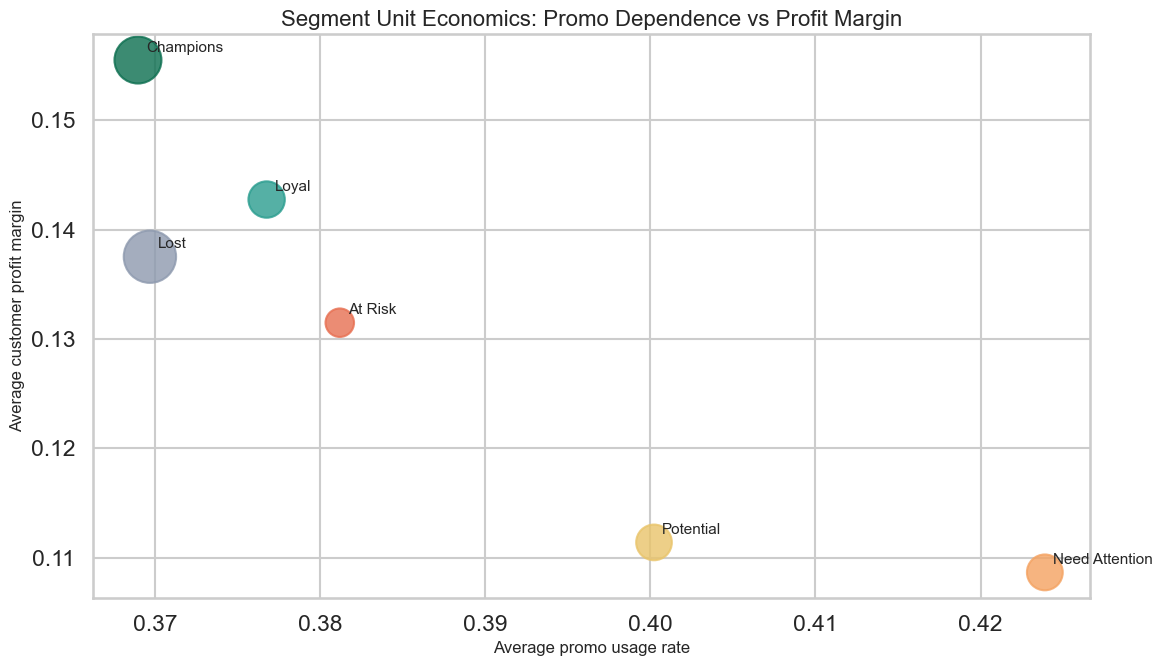

,customers,avg_profit,avg_profit_margin,avg_promo_usage,avg_refund_rate
segment,,,,,
Champions,20598,68907.0746,0.1555,0.3690,0.0311
Loyal,12357,34290.3030,0.1427,0.3768,0.0320
Potential,11886,8591.2033,0.1114,0.4002,0.0337
Need Attention,11982,7845.8669,0.1086,0.4239,0.0327
At Risk,7585,11413.1452,0.1315,0.3812,0.0342
Lost,25580,4530.0298,0.1375,0.3697,0.0349


In [22]:
segment_economics = (
    customer_golden_table.groupby('segment')
    .agg(
        customers=('customer_id', 'count'),
        avg_profit=('monetary_profit', 'mean'),
        avg_profit_margin=('profit_margin', 'mean'),
        avg_promo_usage=('promo_usage_rate', 'mean'),
        avg_refund_rate=('refund_rate', 'mean'),
    )
    .reindex(segment_order)
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    segment_economics['avg_promo_usage'],
    segment_economics['avg_profit_margin'],
    s=segment_economics['customers'] / 18,
    c=[SEGMENT_COLORS[s] for s in segment_economics.index],
    alpha=0.8,
)

for segment_name, row in segment_economics.iterrows():
    ax.annotate(
        segment_name,
        (row['avg_promo_usage'], row['avg_profit_margin']),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=11,
    )

ax.set_title('Segment Unit Economics: Promo Dependence vs Profit Margin')
ax.set_xlabel('Average promo usage rate')
ax.set_ylabel('Average customer profit margin')
plt.tight_layout()
plt.show()

display(segment_economics.round(4))